# 🍽️ Food Safety & Health Hazards Detection
**Dataset:** Amazon Fine Food Reviews (~568k reviews, 1999–2012) · **DB:** MongoDB `amazon_reviews.reviews`

### Four-Stage NLP Pipeline

| # | Stage | Tool | Purpose |
|---|-------|------|---------|
| 1 | Keyword / Regex | Custom dictionary | Explicit flagging — 5 hazard categories |
| 2 | Text Deduplication | Pandas groupby | Remove ~30% redundant texts; preserve product traceability |
| 3 | Semantic Search | `all-MiniLM-L6-v2` (≥ 0.39) | Catch implicit / figurative language |
| 4 | NLI Precision Filter + Late Weighting | `DeBERTa v3-small` (≥ 0.50) + star-rating penalty | Confirm genuine complaints; suppress false positives |

### Contents
1. Setup & Imports · 2. Data Ingestion · 3. Safety Keywords · 4. Scan & Flag (MongoDB)
5. Query Flagged Reviews · 6. Visualize Distribution · 7. Regex Blind Spot
8a. Text Deduplication · 8b. MiniLM Encoding · 9. Regex vs. Semantic Comparison
10. DeBERTa Precision Filter · 10b. Late Weighting · 11. Export to Excel · 12. Business Recommendations

---
## 🎯 Objective & Approach

Mining 568k Amazon food reviews for safety signals enables **proactive intervention before a recall** — not after hospitalisations. Traditional keyword search catches explicit reports ("found glass in my food") but misses implicit ones ("I spent the night running to the bathroom").

| Challenge | Solution |
|-----------|----------|
| Explicit keywords miss ambiguous language | Regex → MiniLM (threshold 0.39) → DeBERTa (threshold 0.50) |
| Duplicate texts inflate GPU compute by ~30% | Text deduplication + fan-out score write-back |
| DeBERTa false positives on high-star reviews | Late weighting: multiply score by star-rating penalty |
| One flagged review may span multiple product variants | `text_to_ids` map flags all linked `ProductId`s simultaneously |

Output: three-tier Excel export (Regex / MiniLM-only / DeBERTa-confirmed) for food safety officers, legal teams, and regulatory intake.

---
## 1. Setup & Imports

### Install Dependencies
Run the cell below only if you haven't installed these packages yet.

In [58]:
# Uncomment and run this cell once to install all required packages
# pip install pymongo pandas matplotlib seaborn
# pip install sentence-transformers
# pip install transformers torch accelerate tqdm

### Import Libraries

In [59]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from pymongo import MongoClient, UpdateOne
from tqdm import tqdm
import torch

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print('All imports successful.')

All imports successful.


---
## 2. MongoDB Connection

Connect to the local MongoDB instance and select the `amazon_reviews` database.  
> Make sure MongoDB is running (`mongod`) before executing this cell.

In [60]:
CLIENT = MongoClient('mongodb://localhost:27017/')
DB     = CLIENT['amazon_reviews']
COL    = DB['reviews']

print('Connected to MongoDB.')
print(f'Total documents in collection: {COL.count_documents({}):,}')

Connected to MongoDB.
Total documents in collection: 568,454


### Step 2b – Load CSV & Import to MongoDB
> **Skip this cell if the collection already has data** — the code checks automatically and will not re-insert.

In [61]:
CSV_PATH = 'Reviews_withURL.csv'

# Only import if collection is empty — safe to re-run without duplicating data
if COL.count_documents({}) == 0:
    print('Loading CSV...')
    df_import = pd.read_csv(CSV_PATH, index_col=0)
    df_import = df_import.dropna(subset=['Text', 'Score'])

    # Convert numeric columns
    for col in ['Id', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time']:
        df_import[col] = pd.to_numeric(df_import[col], errors='coerce')
    df_import = df_import.dropna(subset=['Id'])

    records = df_import.to_dict(orient='records')

    # Insert in batches of 10,000 for memory efficiency
    BATCH = 10_000
    for i in range(0, len(records), BATCH):
        COL.insert_many(records[i:i+BATCH])
        print(f'  Inserted {min(i+BATCH, len(records)):,}/{len(records):,}', end='\r')

    print(f'\nDone. Total documents: {COL.count_documents({}):,}')
else:
    print(f'Collection already has {COL.count_documents({}):,} documents. Skipping import.')

Collection already has 568,454 documents. Skipping import.


### Step 2c – Verify Data

In [62]:
sample = COL.find_one()
print('Sample document keys:', list(sample.keys()))
print('\nSample document:')
for k, v in sample.items():
    if k != '_id':
        print(f'  {k}: {str(v)[:80]}')

Sample document keys: ['_id', 'Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'ProductURL', 'HelpfulnessRatio', 'DominantTopic', 'TopicLabel', 'SentimentLabelVader', 'SentimentScoreVader', 'FoodSafetyFlag', 'SafetyCategories', 'SafetySeverity', 'SemanticFlagged', 'SemanticScore']

Sample document:
  Id: 1
  ProductId: B001E4KFG0
  UserId: A3SGXH7AUHU8GW
  ProfileName: delmartian
  HelpfulnessNumerator: 1
  HelpfulnessDenominator: 1
  Score: 5
  Time: 1303862400
  Summary: Good Quality Dog Food
  Text: I have bought several of the Vitality canned dog food products and have found th
  ProductURL: https://www.amazon.com/dp/B001E4KFG0
  HelpfulnessRatio: 1.0
  DominantTopic: 2
  TopicLabel: Pet Food
  SentimentLabelVader: Positive
  SentimentScoreVader: 0.9441
  FoodSafetyFlag: False
  SafetyCategories: []
  SafetySeverity: None
  SemanticFlagged: True
  SemanticScore: 0.3692772686481476


---
## 3. Safety Keyword Categories
**Goal:** Detect and categorize food safety concerns and health hazards reported in customer reviews. Flag reviews that mention contamination, illness, spoilage, allergic reactions, or product defects. Results are written back to MongoDB as `FoodSafetyFlag`, `SafetyCategories`, and `SafetySeverity`.

In [63]:
import re
import html as _html

# =====================================================================
# FOOD SAFETY KEYWORD DICTIONARY
# Categorized by hazard type and ordered by severity
# =====================================================================
# This dictionary defines the "vocabulary" our scanner uses to detect safety issues.
# Each key is a hazard category, and the value is a list of phrases to look for.
# We use a dictionary (instead of one big list) so we can categorize and
# prioritize issues by how dangerous they are.
SAFETY_KEYWORDS = {
    'Illness': [  # Highest risk: reviewer got physically sick from the food
        'food poison', 'food poisoning', 'food-borne', 'foodborne',
        'vomit', 'vomiting', 'diarrhea', 'diarrhoea', 'nausea', 'nauseous',
        'stomach ache', 'stomachache', 'cramp', 'hospitalized', 'hospital',
        'threw up', 'throw up', 'salmonella', 'e. coli', 'ecoli', 'botulism',
        'made me sick', 'got sick', 'became sick', 'felt ill', 'food-borne illness'
    ],
    'Contamination': [  # Physical foreign objects or biological contamination found in food
        'mold', 'mould', 'moldy', 'mouldy', 'fungus', 'worm', 'maggot',
        'insect', 'cockroach', 'rodent', 'rat', 'mouse', 'larvae', 'bug in',
        'contaminated', 'contamination', 'debris', 'hair in', 'plastic piece',
        'glass shard', 'metal piece', 'foreign object', 'foreign material'
    ],
    'Spoilage': [  # Food past its prime or stored poorly — medium risk
        'expired', 'expiration', 'rotten', 'rancid', 'spoiled', 'spoilt',
        'stale', 'bad smell', 'smells bad', 'smells off', 'bad odor',
        'off smell', 'sour smell', 'strange smell', 'foul smell', 'putrid',
        'mildew', 'gone bad', 'already expired', 'past expiration', 'past expiry'
    ],
    'Allergen': [  # Undisclosed allergens — can be life-threatening for sensitive individuals
        'allergic reaction', 'allergic response', 'severe allergy', 'hives',
        'rash', 'swollen throat', 'throat closing', 'anaphylaxis', 'anaphylactic',
        'epipen', 'epinephrine', 'cross contaminat', 'unlisted ingredient',
        'undisclosed ingredient', 'undeclared allergen'
    ],
    'Quality_Defect': [  # Packaging or labeling problems — lower immediate health risk
        'broken glass', 'cracked container', 'sharp piece', 'defective packaging',
        'wrong product', 'mislabeled', 'wrong label', 'incorrect label',
        'undercooked', 'raw chicken', 'raw meat', 'incorrect ingredient'
    ]
}

# Severity mapping – determines how critical each category is
# This controls which issues trigger urgent alerts vs. routine quality reviews
SEVERITY_MAP = {
    'Illness':        'High',    # Immediate health threat — needs urgent attention
    'Contamination':  'High',    # Physical danger — potential FDA/regulatory involvement
    'Allergen':       'High',    # Can be life-threatening for allergic individuals
    'Spoilage':       'Medium',  # Significant but not immediately dangerous
    'Quality_Defect': 'Low'      # No direct health risk, but hurts brand reputation
}

# =====================================================================
# TEXT SANITIZATION UTILITY
# =====================================================================
# Amazon reviews contain HTML artifacts left over from web scraping:
#   • <br /> line breaks become invisible word boundaries for regex
#   • &amp; / &#39; / &lt; can obscure keyword matches like "I'm sick"
# Cleaning BEFORE regex scanning improves recall without destroying
# semantic content. Case is preserved for Transformer models later.
_HTML_TAG    = re.compile(r'<[^>]+>')   # Matches any <tag> including <br />, <b>, etc.
_MULTI_SPACE = re.compile(r'\s+')       # Matches any whitespace sequence

def sanitize_text(text: str) -> str:
    """
    Lightweight preprocessing for Amazon review text.
    Strips HTML tags, decodes HTML entities, and collapses whitespace.
    Preserves original case and punctuation for Transformer compatibility.
    """
    if not isinstance(text, str):
        return ''
    text = _HTML_TAG.sub(' ', text)     # Remove HTML tags: <br /> → space
    text = _html.unescape(text)         # Decode entities: &amp; → &, &#39; → '
    text = _MULTI_SPACE.sub(' ', text)  # Collapse consecutive whitespace
    return text.strip()

print(f'Safety keyword categories: {list(SAFETY_KEYWORDS.keys())}')
total_kw = sum(len(v) for v in SAFETY_KEYWORDS.values())
print(f'Total keywords defined: {total_kw}')

Safety keyword categories: ['Illness', 'Contamination', 'Spoilage', 'Allergen', 'Quality_Defect']
Total keywords defined: 97


---
## 4. Scan Reviews & Write Safety Flags to MongoDB

In [64]:
# =====================================================================
# STEP 1: PRE-COMPILE REGEX PATTERNS (fast multi-keyword search)
# =====================================================================
# Instead of building a new regex each time a review is checked, we compile
# them ONCE here. Reusing compiled patterns is much faster across 568k+ documents.
compiled_patterns = {}
for category, keywords in SAFETY_KEYWORDS.items():
    # re.escape() makes sure special characters (like '.', '(') are treated as
    # literal text, not regex operators. '|'.join(...) chains all keywords with OR.
    pattern_str = '|'.join(re.escape(kw) for kw in keywords)
    # re.IGNORECASE means "food poison", "FOOD POISON" and "Food Poison" all match
    compiled_patterns[category] = re.compile(pattern_str, re.IGNORECASE)

# =====================================================================
# STEP 2: DEFINE THE FLAGGING FUNCTION
# =====================================================================
# Numeric priority for severity levels — used later to pick the "worst" category
severity_order = {'High': 3, 'Medium': 2, 'Low': 1}

def check_food_safety(text):
    """
    Scans a review for food safety keywords.
    Returns: (is_flagged, matched_categories, highest_severity)
    """
    # Skip empty strings or non-text fields to avoid crashes
    if not isinstance(text, str) or not text.strip():
        return False, [], None
    # Sanitize HTML artifacts before pattern matching to improve recall
    # (e.g., "I'm<br />sick" → "I'm sick" so keywords fire correctly)
    text = sanitize_text(text)
    # Run each compiled pattern against the review text.
    # We keep a list of every category that matched at least once.
    matched = [cat for cat, pattern in compiled_patterns.items() if pattern.search(text)]
    if not matched:
        return False, [], None
    # If multiple categories matched (e.g., both Illness and Contamination),
    # we take the one with the highest severity score as the final label.
    highest = max(matched, key=lambda c: severity_order.get(SEVERITY_MAP.get(c, 'Low'), 0))
    return True, matched, SEVERITY_MAP[highest]

# =====================================================================
# STEP 3: ENSURE INDEX — AVOID FULL COLLECTION SCANS
# =====================================================================
# Without an index, MongoDB must inspect every document to evaluate
# {FoodSafetyFlag: {$exists: False}}. With the index the planner uses a
# sparse scan instead, which is orders of magnitude faster on 568k docs.
# create_index() is idempotent — safe to call on every notebook run.
COL.create_index('FoodSafetyFlag', background=True)
print('Index on FoodSafetyFlag: ready.')

# =====================================================================
# STEP 4: SCAN ALL UN-FLAGGED DOCUMENTS AND BULK WRITE TO MONGODB
# =====================================================================
# Only process documents that don't already have 'FoodSafetyFlag' set,
# so we can safely re-run this cell without duplicating work.
cursor = COL.find(
    {'FoodSafetyFlag': {'$exists': False}},   # Filter: only un-processed documents
    {'Text': 1, '_id': 1}                     # Projection: only fetch Text and _id (saves memory)
)

ops        = []  # Accumulate MongoDB update operations in a list before writing
processed  = 0
flagged_ct = 0

print('Scanning reviews for food safety & health hazard keywords...')
for doc in cursor:
    is_flagged, categories, severity = check_food_safety(doc.get('Text', ''))
    # Prepare an update operation — we won't write to DB yet, just queue it
    ops.append(UpdateOne(
        {'_id': doc['_id']},
        {'$set': {
            'FoodSafetyFlag':   is_flagged,
            'SafetyCategories': categories,
            'SafetySeverity':   severity
        }}
    ))
    if is_flagged:
        flagged_ct += 1
    processed += 1

    # bulk_write sends 10,000 updates at once instead of one-by-one.
    # This is ~100x faster than calling update_one() in a loop.
    if len(ops) == 10_000:
        COL.bulk_write(ops, ordered=False)
        ops = []  # Reset the batch
        print(f'  Processed {processed:,}...', end='\r')

# Write any remaining documents that didn't fill a full batch of 10,000
if ops:
    COL.bulk_write(ops, ordered=False)

print(f'\nDone. Total scanned: {processed:,}')
print(f'Flagged reviews: {flagged_ct:,} ({flagged_ct / max(processed, 1):.2%} of all reviews)')

Index on FoodSafetyFlag: ready.
Scanning reviews for food safety & health hazard keywords...

Done. Total scanned: 0
Flagged reviews: 0 (0.00% of all reviews)


---
## 5. Query & Analyze Flagged Reviews

In [65]:
# =====================================================================
# STEP 1: FETCH FLAGGED REVIEWS FROM MONGODB
# =====================================================================
# Pull only the fields we need into a Pandas DataFrame for analysis.
# (Fetching all fields would be wasteful — we have 568k+ documents)
cursor_flagged = COL.find(
    {'FoodSafetyFlag': True},                               # Only flagged reviews
    {'Text': 1, 'Score': 1, 'SafetyCategories': 1,
     'SafetySeverity': 1, 'Time': 1, 'Summary': 1, '_id': 0}  # Select specific columns
)
df_safety = pd.DataFrame(list(cursor_flagged))

print(f'Total flagged reviews: {len(df_safety):,}')
print(f'\nSeverity breakdown:')
print(df_safety['SafetySeverity'].value_counts().to_string())

# =====================================================================
# STEP 2: EXPAND MULTI-LABEL CATEGORIES FOR COUNTING
# =====================================================================
# A single review can match multiple categories (e.g., Spoilage + Illness).
# The 'SafetyCategories' column stores a LIST per row: e.g., ['Illness', 'Contamination']
# explode() converts each list item into its own row so we can count each category separately.
# Without explode(), a row with ['A', 'B'] would only be counted once — which is incorrect.
df_safety_exp = df_safety.explode('SafetyCategories').dropna(subset=['SafetyCategories'])

print(f'\nIssue category breakdown:')
print(df_safety_exp['SafetyCategories'].value_counts().to_string())

# =====================================================================
# STEP 3: DISPLAY SAMPLE HIGH-SEVERITY REVIEWS
# =====================================================================
# Randomly sample 5 High-severity reviews to get a qualitative understanding
# of what "High severity" actually looks like in practice.
print('\n--- Sample High-Severity Flagged Reviews ---')
high_sev = df_safety[df_safety['SafetySeverity'] == 'High']
sample_high = high_sev.sample(min(5, len(high_sev)), random_state=42)  # random_state=42 ensures reproducibility

for _, row in sample_high.iterrows():
    cats = ', '.join(row['SafetyCategories']) if isinstance(row['SafetyCategories'], list) else str(row['SafetyCategories'])
    print(f"Stars: {row['Score']} | Categories: {cats} | Severity: {row['SafetySeverity']}")
    print(f"Review: {str(row.get('Text', ''))[:300]}...")
    print('-' * 60)

Total flagged reviews: 81,626

Severity breakdown:
SafetySeverity
High      73930
Medium     7255
Low         441

Issue category breakdown:
SafetyCategories
Contamination     65156
Spoilage          12726
Illness            7491
Allergen           4414
Quality_Defect      615

--- Sample High-Severity Flagged Reviews ---
Stars: 5 | Categories: Contamination | Severity: High
Review: I've never been a big fan on chips. When it comes to snack foods, I'm more of a pretzel guy, or maybe something cheesy. Potato chips, in particular, just never appealed to me. But these aren't potato chips.<br /><br />If you read the bag, and I'm one of those strange people that actually do read the...
------------------------------------------------------------
Stars: 5 | Categories: Contamination | Severity: High
Review: My great-grandmother made it, my grandmother made it, my mother made it, and now I make it! (I hope my daughters will make it and this chain will never end, connecting one generation to t

---
## 6. Visualize Safety Issue Distribution

C:\Users\Hanz\AppData\Local\Temp\ipykernel_26248\2612616566.py:80: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


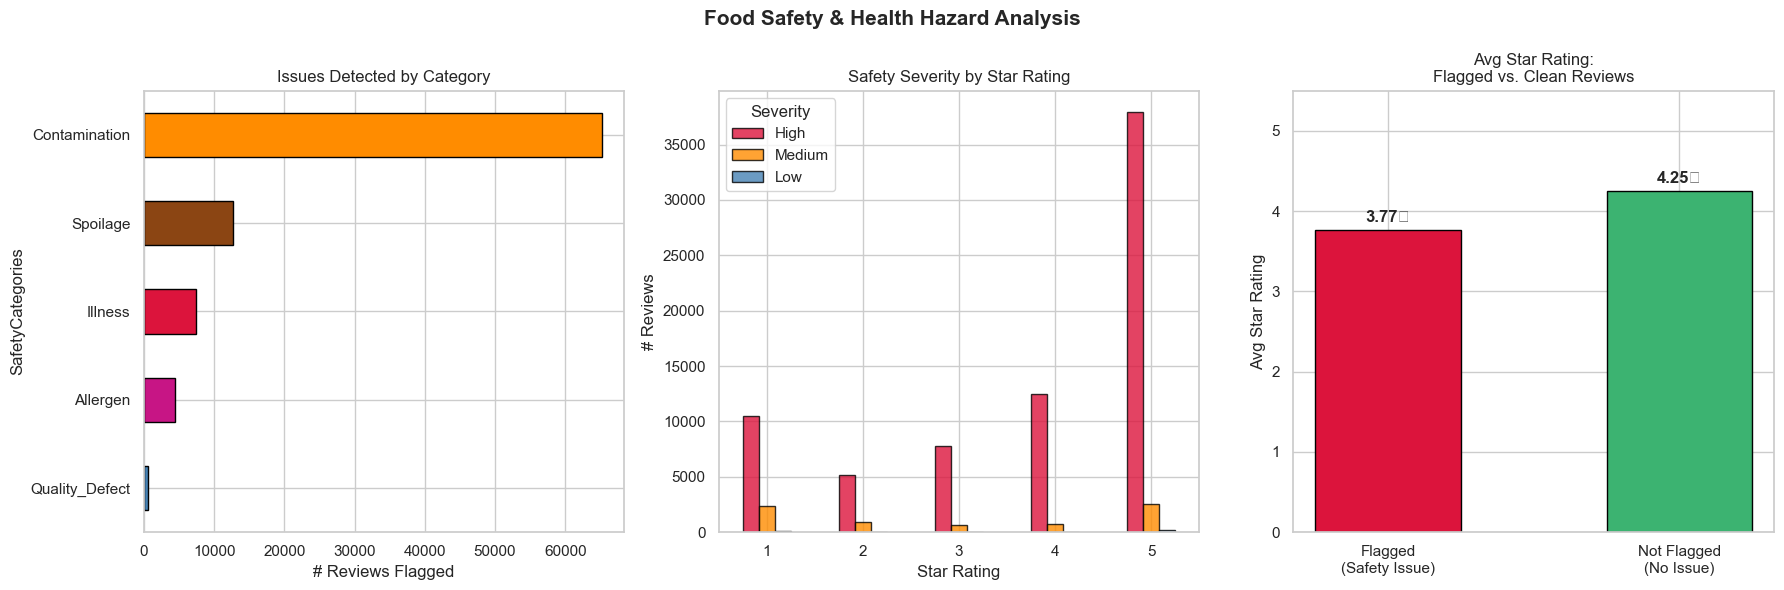

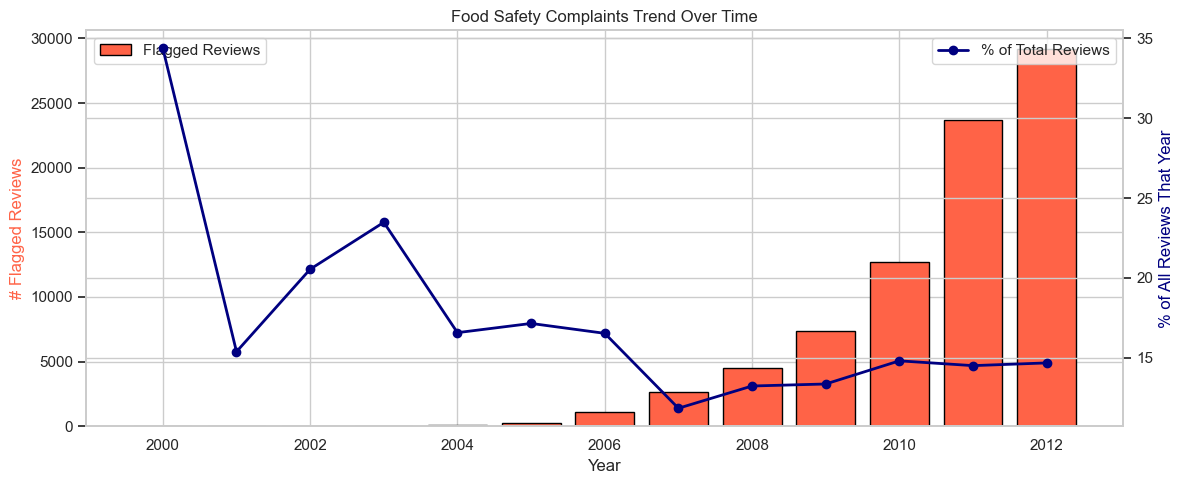

In [66]:
# Convert Unix timestamps (seconds since 1970) to readable dates, then extract the year
df_safety['Date'] = pd.to_datetime(df_safety['Time'], unit='s', errors='coerce')
df_safety['Year'] = df_safety['Date'].dt.year

# Fetch the average star rating of clean (non-flagged) reviews for comparison
non_flagged_avg_score = pd.DataFrame(
    list(COL.find({'FoodSafetyFlag': False}, {'Score': 1, '_id': 0}))
)['Score'].mean()
flagged_avg_score = df_safety['Score'].mean()

# Use MongoDB's aggregation pipeline to count how many reviews were written
# in each year (across the ENTIRE dataset, not just flagged ones).
# This lets us calculate what PERCENTAGE of each year's reviews were flagged.
year_total_pipeline = [
    {'$match': {'Time': {'$gt': 0}}},
    {'$addFields': {'Year': {'$year': {'$toDate': {'$multiply': ['$Time', 1000]}}}}},
    {'$group': {'_id': '$Year', 'Total': {'$sum': 1}}},
    {'$sort': {'_id': 1}}
]
df_year_total = pd.DataFrame(
    list(COL.aggregate(year_total_pipeline))
).rename(columns={'_id': 'Year'})

# =====================================================================
# FIGURE 1: OVERVIEW DASHBOARD (3-PANEL)
# =====================================================================
# Create a wide canvas with 3 side-by-side panels for the overview
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Food Safety & Health Hazard Analysis', fontsize=15, fontweight='bold')

# ── Panel 1: Issue Count by Category ──
# Count how many reviews were flagged for each safety category
cat_counts = df_safety_exp['SafetyCategories'].value_counts()
# Assign a distinct color to each category for easy visual distinction
cat_colors_map = {
    'Illness': 'crimson', 'Contamination': 'darkorange',
    'Allergen': 'mediumvioletred', 'Spoilage': 'saddlebrown', 'Quality_Defect': 'steelblue'
}
bar_colors_fig = [cat_colors_map.get(c, 'gray') for c in cat_counts.index]
# Draw a horizontal bar chart (barh) so long category names are easy to read
cat_counts.plot(kind='barh', ax=axes[0], color=bar_colors_fig, edgecolor='black')
axes[0].set_title('Issues Detected by Category')
axes[0].set_xlabel('# Reviews Flagged')
axes[0].invert_yaxis()  # Flip so the most common issue is at the top

# ── Panel 2: Severity Distribution per Star Rating ──
# Group flagged reviews by their severity level (High/Medium/Low) and star rating
sev_score = df_safety.groupby(['SafetySeverity', 'Score']).size().unstack(fill_value=0)
sev_order = [s for s in ['High', 'Medium', 'Low'] if s in sev_score.index]
# Transpose (.T) so star ratings are on the X-axis instead of severity levels
sev_score.loc[sev_order].T.plot(
    kind='bar', ax=axes[1],
    color=['crimson', 'darkorange', 'steelblue'][:len(sev_order)],
    edgecolor='black', alpha=0.8
)
axes[1].set_title('Safety Severity by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('# Reviews')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Severity')

# ── Panel 3: Avg Star Rating – Flagged vs. Clean Reviews ──
# Compare the average star rating of reviews WITH safety issues vs. those WITHOUT.
# This shows whether safety complaints correlate with lower star ratings.
bars_cmp = axes[2].bar(
    ['Flagged\n(Safety Issue)', 'Not Flagged\n(No Issue)'],
    [flagged_avg_score, non_flagged_avg_score],
    color=['crimson', 'mediumseagreen'], edgecolor='black', width=0.5
)
axes[2].set_title('Avg Star Rating:\nFlagged vs. Clean Reviews')
axes[2].set_ylabel('Avg Star Rating')
axes[2].set_ylim(0, 5.5)
# Place the exact average score number on top of each bar
for bar, val in zip(bars_cmp, [flagged_avg_score, non_flagged_avg_score]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
        f'{val:.2f}★', ha='center', fontweight='bold', fontsize=12
    )

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 2: YEARLY TREND OF FOOD SAFETY REPORTS
# =====================================================================
# Calculate how many reviews were flagged per year
yearly_safety = df_safety.groupby('Year').size().reset_index(name='FlaggedCount')
# Merge with the total-per-year data to compute the percentage of flagged reviews
merged = yearly_safety.merge(df_year_total, on='Year', how='left')
merged['FlaggedPct'] = merged['FlaggedCount'] / merged['Total'] * 100

# Create a dual-axis chart: bars show raw count (left axis), line shows % (right axis)
fig2, ax_main = plt.subplots(figsize=(12, 5))
ax_main.bar(merged['Year'], merged['FlaggedCount'],
            color='tomato', edgecolor='black', label='Flagged Reviews')

# twinx() creates a SECOND Y-axis that shares the same X-axis with the bars above
ax_pct = ax_main.twinx()
ax_pct.plot(merged['Year'], merged['FlaggedPct'],
            color='navy', marker='o', linewidth=2, label='% of Total Reviews')

ax_main.set_title('Food Safety Complaints Trend Over Time')
ax_main.set_xlabel('Year')
ax_main.set_ylabel('# Flagged Reviews', color='tomato')
ax_pct.set_ylabel('% of All Reviews That Year', color='navy')
ax_main.legend(loc='upper left')
ax_pct.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 7. Regex Blind Spot & Semantic Pipeline

Regex only matches *explicit* keywords. Implicit language is completely missed:

| Customer writes | Regex | Actual meaning |
|---|:---:|---|
| *"I spent the night running to the bathroom"* | ❌ | Food poisoning |
| *"My lips and face started swelling after eating"* | ❌ | Allergic reaction |
| *"The taste was completely, horrifyingly off"* | ❌ | Spoilage |

**Two-stage semantic pipeline** (Steps 8a–10):

| Stage | Model | Threshold | Role |
|-------|-------|:---------:|------|
| 8b | `all-MiniLM-L6-v2` | ≥ 0.39 | High-recall net on deduplicated texts |
| 10 | `cross-encoder/nli-deberta-v3-small` | ≥ 0.50 | High-precision NLI confirmation |

> DeBERTa runs only on MiniLM candidates (~3–10% of dataset) — computationally feasible. MiniLM operates on **~390k unique texts** (not 568k) after deduplication in Step 8a.

---
## 8a. Text Deduplication

Amazon uses **Parent/Child ASIN linkage** — the same review text can appear under multiple `ProductId`s (different sizes, flavours). The raw dataset has **~568k rows** but only **~390k unique texts** (~30% redundancy).

| Goal | Mechanism |
|------|-----------|
| **Efficiency** | Encode each unique text **once** → ~30% fewer GPU forward passes |
| **Traceability** | `text_to_ids` maps each text → `[_id1, _id2, ...]` — all product variants linked |
| **Completeness** | Score fanned out to **every** linked `_id` via `bulk_write` — no document left unscored |

```
"Found a bug inside"  →  score = 0.91
   ↓ fan-out to all linked _ids
   _id_A  SemanticFlagged = True
   _id_B  SemanticFlagged = True   (different ProductId, same hazard)
```

> One flagged review → all affected product variants blocked simultaneously.

In [67]:
from collections import defaultdict

# =====================================================================
# STEP 8a: BUILD TEXT DEDUPLICATION MAP
# =====================================================================
# Stream all documents from MongoDB and group every _id under its text.
# This builds text_to_ids: { "review text" → [_id1, _id2, ...] }
#
# Key outputs produced here:
#   text_to_ids   — dict mapping each unique text to a list of all
#                   MongoDB _ids that share that exact text string
#   unique_texts  — plain list of unique text strings fed to MiniLM
# =====================================================================

print('Building text deduplication map from MongoDB...')
print('(Streaming all documents — one pass, minimal RAM)\n')

text_to_ids: dict = defaultdict(list)   # text → [_id, _id, ...]

cursor_dedup = COL.find(
    {'Text': {'$exists': True, '$ne': ''}},
    {'_id': 1, 'Text': 1}              # Minimal projection — only what we need
)

for doc in cursor_dedup:
    text_key = str(doc.get('Text', ''))
    text_to_ids[text_key].append(doc['_id'])

# Convert to a plain list so we can iterate with index-based batching
unique_texts = list(text_to_ids.keys())

# =====================================================================
# DEDUPLICATION STATISTICS
# =====================================================================
total_docs_raw  = sum(len(v) for v in text_to_ids.values())
n_unique        = len(unique_texts)
n_duplicates    = total_docs_raw - n_unique
pct_reduction   = n_duplicates / total_docs_raw * 100

# Compute how many texts have more than one linked _id (actual duplicates)
n_multi = sum(1 for v in text_to_ids.values() if len(v) > 1)
avg_fan  = total_docs_raw / n_unique

print('=' * 55)
print('TEXT DEDUPLICATION SUMMARY')
print('=' * 55)
print(f'  Total documents in MongoDB     : {total_docs_raw:,}')
print(f'  Unique texts (model input)     : {n_unique:,}')
print(f'  Duplicate texts eliminated     : {n_duplicates:,}  ({pct_reduction:.1f}% reduction)')
print(f'  Texts with >1 linked _id       : {n_multi:,}')
print(f'  Avg. documents per unique text : {avg_fan:.2f}')
print()
print('  MiniLM will encode each unique text ONCE.')
print('  The score is then fanned out to ALL linked _ids via bulk_write.')
print('  Product traceability is preserved inside text_to_ids.')

# =====================================================================
# SAMPLE: Show how one duplicated text maps to multiple _ids
# =====================================================================
# Find the most-duplicated text as an illustrative example
most_dup_text = max(text_to_ids, key=lambda t: len(text_to_ids[t]))
most_dup_ids  = text_to_ids[most_dup_text]

print(f'\n  Most-duplicated text  : "{most_dup_text[:80]}..."')
print(f'  Linked across {len(most_dup_ids):,} MongoDB document(s)')

# Retrieve ProductIds for those _ids to show business traceability
sample_docs = list(COL.find(
    {'_id': {'$in': most_dup_ids[:10]}},   # Limit to 10 for display
    {'ProductId': 1, '_id': 0}
))
product_ids = [d.get('ProductId', 'N/A') for d in sample_docs]
print(f'  Sample ProductIds     : {product_ids}')
print()
print('Step 8a complete. Proceed to Step 8b (MiniLM encoding).')

Building text deduplication map from MongoDB...
(Streaming all documents — one pass, minimal RAM)

TEXT DEDUPLICATION SUMMARY
  Total documents in MongoDB     : 568,454
  Unique texts (model input)     : 393,579
  Duplicate texts eliminated     : 174,875  (30.8% reduction)
  Texts with >1 linked _id       : 58,040
  Avg. documents per unique text : 1.44

  MiniLM will encode each unique text ONCE.
  The score is then fanned out to ALL linked _ids via bulk_write.
  Product traceability is preserved inside text_to_ids.

  Most-duplicated text  : "This review will make me sound really stupid, but whatever. I don't really care ..."
  Linked across 199 MongoDB document(s)
  Sample ProductIds     : ['B0002TJAZK', 'B0002TJAZK', 'B00106TG9Y', 'B003ANFMY8', 'B003ANFMY8', 'B003ANFMY8', 'B003ANFMY8', 'B003ANFMY8', 'B003ANFMY8', 'B003ANFMY8']

Step 8a complete. Proceed to Step 8b (MiniLM encoding).


In [68]:
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np
from tqdm import tqdm

# =====================================================================
# STEP 8b: MODEL + PROBE SENTENCES SETUP
# =====================================================================
SEMANTIC_THRESHOLD = 0.39    # Lower threshold → wider net (high recall)
ENCODE_BATCH_SIZE  = 256     # Unique texts per GPU/CPU encode pass
MAX_CHARS_SEM      = 384     # Truncate reviews to keep inference fast

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Loading sentence-transformer model (all-MiniLM-L6-v2) on {device.upper()}...')
print('(First run: ~80 MB download)\n')

sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# ─────────────────────────────────────────────────────────────────────
# PROBE SENTENCES — written in natural customer language to capture
# IMPLICIT / FIGURATIVE complaints that regex would completely miss.
# Examples of what regex can not catch:
#   "I spent the night running to the bathroom"   → foodborne illness
#   "found something that shouldn't be in food"   → contamination
#   "my lips started swelling after eating this"  → allergic reaction
# ─────────────────────────────────────────────────────────────────────
SAFETY_PROBES = [
    # Illness
    "Contracted severe food poisoning and vomiting",
    "Diagnosed with salmonella gastroenteritis infection",
    "Intense nausea and violent diarrhea all night",

    # Contamination (focus on foreign objects, avoid generic "food"/"package")
    "Disgusting maggots and worms crawling inside",
    "Sharp glass shards and hard plastic pieces hidden",
    "Tasted like toxic chemical bleach and soap",

    # Spoilage (focus on sensory signals, avoid "fresh"/"arrived")
    "Smells completely rancid, rotten, and putrid",
    "Covered in fuzzy green mold and fungus",
    "The can was bulging, bloated, and leaking",

    # Allergen
    "Anaphylactic shock, throat swelling, and breathing difficulty",
    "Severe allergic reaction and skin hives breakout",
    "Dangerous undisclosed hidden allergens ingredients",

    # Quality defect
    "Chipped my tooth on a hard dangerous object",
    "Tampered broken safety seal risk",
]

probe_embeddings = sbert_model.encode(
    SAFETY_PROBES, convert_to_tensor=True, show_progress_bar=False
)
print(f'Model ready | {len(SAFETY_PROBES)} safety probe sentences encoded')
print(f'Cosine similarity threshold : {SEMANTIC_THRESHOLD}')
print(f'Strategy: DEDUPLICATED unique texts — score fanned out to all linked _ids\n')

# =====================================================================
# STEP 8c: ENCODE UNIQUE TEXTS — WRITE-BACK STRATEGY (OOM-safe)
# =====================================================================
# Replaces the naive "encode all 568k docs" approach.
# text_to_ids (from Step 8a) provides:
#   - unique_texts  : the ~390k distinct strings to encode
#   - text_to_ids   : maps each string → list of all MongoDB _ids sharing it
#
# For each batch of unique texts:
#   1. Encode batch_size texts in one GPU forward pass
#   2. Fan-out each score to EVERY _id in text_to_ids[text]
#      → 1 encode call updates multiple MongoDB documents simultaneously
# =====================================================================

# Sparse index speeds up the final "SemanticScore $exists" query
COL.create_index([('SemanticScore', 1)], sparse=True, background=True)
print('Index on SemanticScore: ready.')

print(f'Unique texts to encode  : {len(unique_texts):,}')
print(f'Batch size              : {ENCODE_BATCH_SIZE}')
print(f'Est. time               : ~5–15 min on GPU | ~1–3 hrs on CPU\n')

batch_texts      = []   # Truncated text strings for the current batch
batch_text_keys  = []   # Same texts (full, un-truncated) as keys into text_to_ids

with tqdm(total=len(unique_texts), desc='miniLM encoding (deduped)', unit='unique texts') as pbar:
    for text in unique_texts:
        batch_texts.append(text[:MAX_CHARS_SEM])
        batch_text_keys.append(text)

        if len(batch_texts) == ENCODE_BATCH_SIZE:
            embs   = sbert_model.encode(
                batch_texts, batch_size=ENCODE_BATCH_SIZE,
                convert_to_tensor=True, show_progress_bar=False
            )
            scores = util.cos_sim(embs, probe_embeddings).max(dim=1).values.cpu().numpy()

            # Fan-out: one score → all MongoDB _ids that share this text
            ops = []
            for text_key, score in zip(batch_text_keys, scores):
                for doc_id in text_to_ids[text_key]:
                    ops.append(UpdateOne(
                        {'_id': doc_id},
                        {'$set': {
                            'SemanticScore':   float(score),
                            'SemanticFlagged': bool(float(score) >= SEMANTIC_THRESHOLD),
                        }}
                    ))
            COL.bulk_write(ops, ordered=False)

            # Discard batch data — free RAM immediately
            batch_texts      = []
            batch_text_keys  = []
            pbar.update(ENCODE_BATCH_SIZE)

    # Flush the final partial batch
    if batch_texts:
        embs   = sbert_model.encode(
            batch_texts, batch_size=len(batch_texts),
            convert_to_tensor=True, show_progress_bar=False
        )
        scores = util.cos_sim(embs, probe_embeddings).max(dim=1).values.cpu().numpy()
        ops = []
        for text_key, score in zip(batch_text_keys, scores):
            for doc_id in text_to_ids[text_key]:
                ops.append(UpdateOne(
                    {'_id': doc_id},
                    {'$set': {
                        'SemanticScore':   float(score),
                        'SemanticFlagged': bool(float(score) >= SEMANTIC_THRESHOLD),
                    }}
                ))
        COL.bulk_write(ops, ordered=False)
        pbar.update(len(batch_texts))

# =====================================================================
# STEP 8d: BUILD df_sem — LIGHTWEIGHT QUERY (no Text field)
# =====================================================================
# With SemanticScore written back to every document (including duplicates
# via fan-out), we rebuild df_sem from a minimal MongoDB projection.
# The full dataset text would consume ~340 MB; Steps 9 and 10 fetch
# Text on-demand for the small subsets that actually need it.
print('\nBuilding df_sem from MongoDB (lightweight — no Text field)...')
cursor_result = COL.find(
    {'SemanticScore': {'$exists': True}},
    {'_id': 1, 'Score': 1, 'FoodSafetyFlag': 1,
     'SafetyCategories': 1, 'SafetySeverity': 1,
     'SemanticScore': 1, 'SemanticFlagged': 1}
)

df_sem = pd.DataFrame(list(cursor_result))
df_sem['FoodSafetyFlag']   = df_sem['FoodSafetyFlag'].fillna(False).astype(bool)
df_sem['SemanticFlagged']  = df_sem['SemanticFlagged'].fillna(False).astype(bool)
df_sem['SafetyCategories'] = df_sem['SafetyCategories'].apply(
    lambda x: x if isinstance(x, list) else []
)

print(f'\n--- Stage 1 Results — FULL dataset ({len(df_sem):,} reviews) ---')
print(f'  Unique texts encoded      : {len(unique_texts):,}')
print(f'  Regex    flagged          : {df_sem["FoodSafetyFlag"].sum():,}  '
      f'({df_sem["FoodSafetyFlag"].mean():.2%})')
print(f'  Semantic flagged          : {df_sem["SemanticFlagged"].sum():,}  '
      f'({df_sem["SemanticFlagged"].mean():.2%})')
print(f'\n  miniLM pass complete — proceed to Step 10 for DeBERTa precision filter.')

Loading sentence-transformer model (all-MiniLM-L6-v2) on CUDA...
(First run: ~80 MB download)

Model ready | 14 safety probe sentences encoded
Cosine similarity threshold : 0.39
Strategy: DEDUPLICATED unique texts — score fanned out to all linked _ids

Index on SemanticScore: ready.
Unique texts to encode  : 393,579
Batch size              : 256
Est. time               : ~5–15 min on GPU | ~1–3 hrs on CPU



miniLM encoding (deduped): 100%|██████████| 393579/393579 [07:20<00:00, 894.17unique texts/s]



Building df_sem from MongoDB (lightweight — no Text field)...

--- Stage 1 Results — FULL dataset (568,454 reviews) ---
  Unique texts encoded      : 393,579
  Regex    flagged          : 81,626  (14.36%)
  Semantic flagged          : 23,587  (4.15%)

  miniLM pass complete — proceed to Step 10 for DeBERTa precision filter.


---
## 9. Regex vs. Semantic Vector Search: Performance Comparison

=== COVERAGE OVERLAP ===
  Caught by Regex ONLY:      75,293  (76.1% of all flags)
  Caught by BOTH methods:    6,333  (6.4% of all flags)
  Caught by Semantic ONLY:   17,254  (17.4% of all flags)
  Missed by BOTH:            469,574

  → Semantic search adds 17,254 implicit safety complaints not found by regex.

=== PRECISION PROXY (% of flagged reviews scoring 1–2★) ===
  Regex only           : 23.5%
  Semantic (all)       : 46.1%
  Semantic-Only (new)  : 42.6%
  Both agreed (overlap): 55.4%  ← highest confidence subset

--- Top 5: Implicit Safety Reviews (Semantic ONLY — regex missed these) ---

█ 3★ | Semantic Sim: 0.683
  Every can was dented, some to the point that a can opened wouldn't open the can.  I filed a complaint with Amazon and they sent out a replacement very quickly.  The replacement was much better with only a few dents.  The packing for the 1st case was in a box that was too long for...
──────────────────────────────────────────────────────────────────────
█ 3★ | Sem

C:\Users\Hanz\AppData\Local\Temp\ipykernel_26248\1318957538.py:120: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


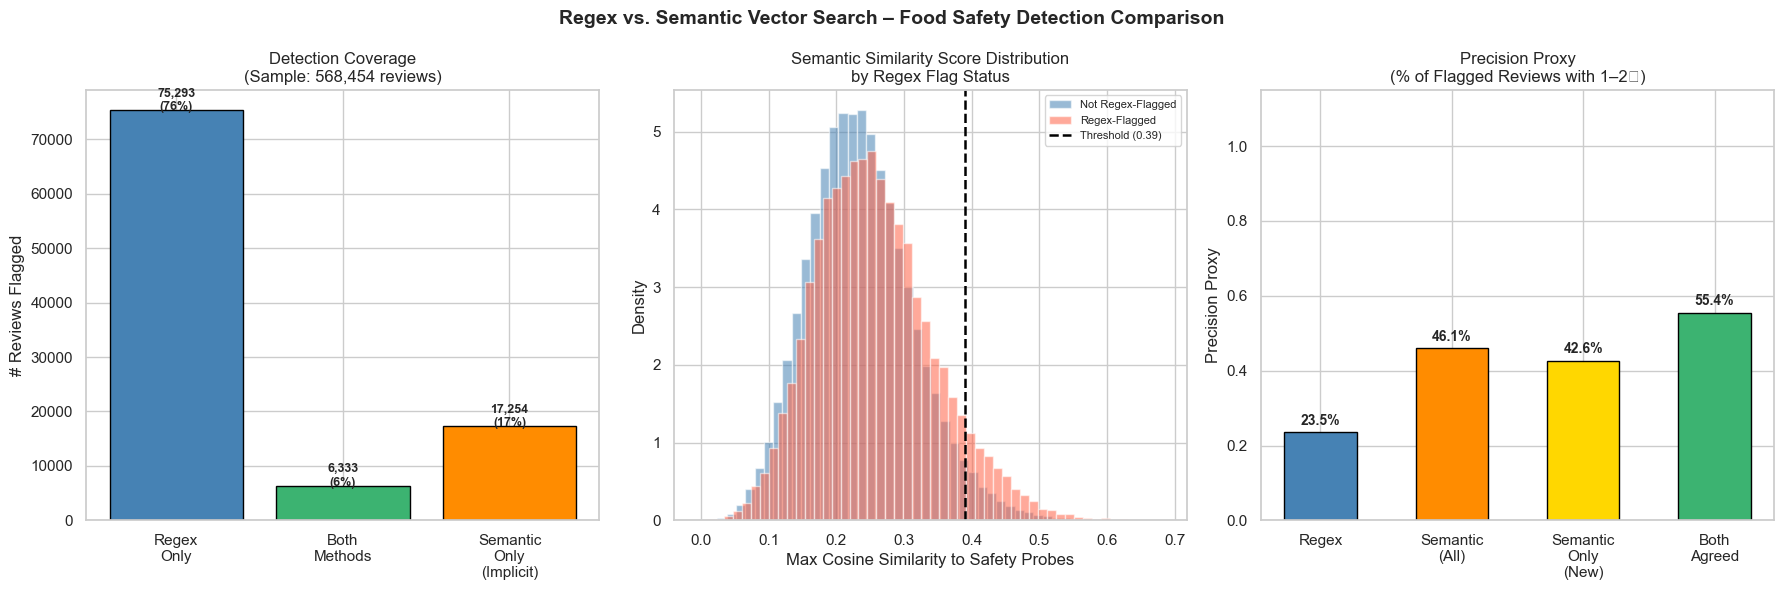

In [69]:
# =====================================================================
# PART 1: OVERLAP ANALYSIS — "Who Finds What?"
# =====================================================================
# 'regex_idx' is the set of row indices (documents) found by keyword matching
# 'semantic_idx' is the set of row indices found by the miniLM semantic search
regex_idx    = set(df_sem.index[df_sem['FoodSafetyFlag']])
semantic_idx = set(df_sem.index[df_sem['SemanticFlagged']])

# Set arithmetic: find what each method caught exclusively vs. together
only_regex    = len(regex_idx - semantic_idx)   # Found by regex, missed by semantic
only_semantic = len(semantic_idx - regex_idx)   # Found by semantic, missed by regex
both_methods  = len(regex_idx & semantic_idx)   # Found by BOTH — highest confidence
neither       = len(df_sem) - only_regex - only_semantic - both_methods
total_flags   = only_regex + both_methods + only_semantic

print('=== COVERAGE OVERLAP ===')
print(f'  Caught by Regex ONLY:      {only_regex:,}  ({only_regex/total_flags*100:.1f}% of all flags)')
print(f'  Caught by BOTH methods:    {both_methods:,}  ({both_methods/total_flags*100:.1f}% of all flags)')
print(f'  Caught by Semantic ONLY:   {only_semantic:,}  ({only_semantic/total_flags*100:.1f}% of all flags)')
print(f'  Missed by BOTH:            {neither:,}')
print(f'\n  → Semantic search adds {only_semantic:,} implicit safety complaints not found by regex.')

# =====================================================================
# PART 2: PRECISION PROXY (1–2 star reviews as noisy ground truth)
# =====================================================================
# Assumption: Reviews with 1–2 stars are more likely to represent genuine safety
# issues (proxy only — not all 1–2 star reviews are safety-related, but it is the
# best available label without manual annotation).
def precision_proxy(idx_set):
    if not idx_set:
        return 0.0
    return float(df_sem.loc[list(idx_set), 'Score'].isin([1, 2]).mean())

prec_regex    = precision_proxy(regex_idx)
prec_semantic = precision_proxy(semantic_idx)
prec_sem_only = precision_proxy(semantic_idx - regex_idx)
prec_both     = precision_proxy(regex_idx & semantic_idx)

print('\n=== PRECISION PROXY (% of flagged reviews scoring 1–2★) ===')
print(f'  Regex only           : {prec_regex:.1%}')
print(f'  Semantic (all)       : {prec_semantic:.1%}')
print(f'  Semantic-Only (new)  : {prec_sem_only:.1%}')
print(f'  Both agreed (overlap): {prec_both:.1%}  ← highest confidence subset')

# =====================================================================
# PART 3: SHOW TOP IMPLICIT REVIEWS — CAUGHT ONLY BY SEMANTIC SEARCH
# =====================================================================
implicit_df = df_sem.loc[list(semantic_idx - regex_idx)].copy()
implicit_df = implicit_df.sort_values('SemanticScore', ascending=False)

# Fetch Text for the top 5 from MongoDB on-demand
# (df_sem does not carry Text to keep RAM usage minimal — see Step 8)
top5_ids   = implicit_df.head(5)['_id'].tolist()
top5_texts = {
    d['_id']: d.get('Text', '')
    for d in COL.find({'_id': {'$in': top5_ids}}, {'Text': 1})
}

print('\n--- Top 5: Implicit Safety Reviews (Semantic ONLY — regex missed these) ---\n')
for _, row in implicit_df.head(5).iterrows():
    print(f"█ {row['Score']}★ | Semantic Sim: {row['SemanticScore']:.3f}")
    print(f"  {str(top5_texts.get(row['_id'], ''))[:280]}...")
    print('─' * 70)

# =====================================================================
# PART 4: VISUALIZATION – 3-PANEL COMPARISON DASHBOARD
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Regex vs. Semantic Vector Search – Food Safety Detection Comparison',
             fontsize=14, fontweight='bold')

# ── Panel 1: Coverage breakdown ──
bars1 = axes[0].bar(
    ['Regex\nOnly', 'Both\nMethods', 'Semantic\nOnly\n(Implicit)'],
    [only_regex, both_methods, only_semantic],
    color=['steelblue', 'mediumseagreen', 'darkorange'],
    edgecolor='black'
)
axes[0].set_title(f'Detection Coverage\n(Sample: {len(df_sem):,} reviews)')
axes[0].set_ylabel('# Reviews Flagged')
for bar, val in zip(bars1, [only_regex, both_methods, only_semantic]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
        f'{val:,}\n({val/total_flags*100:.0f}%)',
        ha='center', fontsize=9, fontweight='bold'
    )

# ── Panel 2: Semantic score distribution ──
df_sem[~df_sem['FoodSafetyFlag']]['SemanticScore'].hist(
    bins=50, ax=axes[1], alpha=0.55, color='steelblue',
    label='Not Regex-Flagged', density=True
)
df_sem[df_sem['FoodSafetyFlag']]['SemanticScore'].hist(
    bins=50, ax=axes[1], alpha=0.55, color='tomato',
    label='Regex-Flagged', density=True
)
axes[1].axvline(
    x=SEMANTIC_THRESHOLD, color='black', linestyle='--',
    linewidth=1.8, label=f'Threshold ({SEMANTIC_THRESHOLD})'
)
axes[1].set_title('Semantic Similarity Score Distribution\nby Regex Flag Status')
axes[1].set_xlabel('Max Cosine Similarity to Safety Probes')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# ── Panel 3: Precision proxy comparison ──
prec_labels = ['Regex', 'Semantic\n(All)', 'Semantic\nOnly\n(New)', 'Both\nAgreed']
prec_vals   = [prec_regex, prec_semantic, prec_sem_only, prec_both]
prec_colors = ['steelblue', 'darkorange', 'gold', 'mediumseagreen']
bars3 = axes[2].bar(prec_labels, prec_vals, color=prec_colors, edgecolor='black', width=0.55)
axes[2].set_title('Precision Proxy\n(% of Flagged Reviews with 1–2★)')
axes[2].set_ylabel('Precision Proxy')
axes[2].set_ylim(0, 1.15)
for bar, val in zip(bars3, prec_vals):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
        f'{val:.1%}', ha='center', fontweight='bold', fontsize=10
    )

plt.tight_layout()
plt.show()

---
## 10. DeBERTa v3 Precision Filter

MiniLM at threshold 0.39 maximises recall but produces false positives — reviews *adjacent* to safety language without being genuine complaints (e.g. *"This tea cured my nausea!"*). DeBERTa re-scores the MiniLM candidate pool using NLI zero-shot classification.

| Stage | Model | Threshold | Input |
|-------|-------|:---------:|-------|
| Done (Step 8b) | `all-MiniLM-L6-v2` | ≥ 0.39 | ~390k unique texts |
| **This step** | `cross-encoder/nli-deberta-v3-small` | ≥ 0.50 | MiniLM candidates only |

Labels used: `Illness`, `Contamination`, `Spoilage`, `Allergen`, `Quality_Defect`, `Safe` (catch-all for false positives). The `Safe` label scores to `0.0` — effectively removing the false positive.

In [71]:
# =====================================================================
# STEP 10: DeBERTa v3 PRECISION FILTER
# Stage 2 of the Two-Stage Food Safety Pipeline
# =====================================================================
from transformers import pipeline as hf_pipeline
from tqdm import tqdm

# -- Candidate pool: everything miniLM flagged at threshold 0.39 ------
candidates_df = df_sem[df_sem['SemanticFlagged']].copy().reset_index(drop=True)

# Fetch Text from MongoDB for the candidate pool
# (df_sem does not carry Text to keep RAM usage minimal — see Step 8)
print('Fetching candidate Text from MongoDB...')
cand_ids  = candidates_df['_id'].tolist()
text_map  = {d['_id']: d.get('Text', '') for d in COL.find({'_id': {'$in': cand_ids}}, {'Text': 1})}
candidates_df['Text'] = candidates_df['_id'].map(text_map).fillna('')
print(f'Text loaded for {candidates_df["Text"].ne("").sum():,} candidates.\n')

print('=' * 60)
print('STAGE 2 — DeBERTa v3 PRECISION FILTER')
print('=' * 60)
print(f'  miniLM candidates forwarded : {len(candidates_df):,}  '
      f'({len(candidates_df) / len(df_sem):.1%} of full dataset)')
print()

# Load DeBERTa v3 zero-shot classifier
device_id = 0 if torch.cuda.is_available() else -1
print('Loading DeBERTa v3 model (cross-encoder/nli-deberta-v3-small)...')
print('(~300 MB — already cached if Section 3 was run)')

# Initialize the Zero-Shot Classification pipeline using DeBERTa v3 small
deberta_safety_pipe = hf_pipeline(
    'zero-shot-classification',
    model='cross-encoder/nli-deberta-v3-small',
    device=device_id,
)

# 1. Define descriptive phrases for DeBERTa (including a 'Safe' category as a catch-all)
# Using natural language descriptions helps the model understand context better than single keywords.
SAFETY_LABELS = [
    "is safe and helped the consumer recover from previous health issues",              # Catch-all for safe/positive reviews
    "caused severe illness, food poisoning, or sickness",                    # Maps to -> Illness
    "contained physical contamination, mold, insects, or foreign objects",   # Maps to -> Contamination
    "was spoiled, expired, rotten, or smelled bad",                          # Maps to -> Spoilage
    "triggered a severe allergic reaction or contained undisclosed allergens", # Maps to -> Allergen
    "had packaging defects, broken glass, or undercooked food"               # Maps to -> Quality_Defect
]

# 2. Create a dictionary to map DeBERTa's descriptive results back to your Regex category format
LABEL_TO_CATEGORY = {
    "is safe and helped the consumer recover from previous health issues": "Safe",
    "caused severe illness, food poisoning, or sickness": "Illness",
    "contained physical contamination, mold, insects, or foreign objects": "Contamination",
    "was spoiled, expired, rotten, or smelled bad": "Spoilage",
    "triggered a severe allergic reaction or contained undisclosed allergens": "Allergen",
    "had packaging defects, broken glass, or undercooked food": "Quality_Defect"
}

print(f"Model ready. Device : {'GPU (CUDA)' if device_id >= 0 else 'CPU'}")
print(f'Labels              : {SAFETY_LABELS}')
print(f'Candidate pool      : {len(candidates_df):,} reviews\n')

# =====================================================================
# RUN DeBERTa INFERENCE — BATCH PROCESSING
# =====================================================================
MAX_CHARS_DEBERTA = 256
DEBERTA_BATCH     = 16

texts_deberta         = candidates_df['Text'].str[:MAX_CHARS_DEBERTA].tolist()
deberta_safety_scores = []
deberta_categories = []  # NEW: List untuk menyimpan kategori hasil DeBERTa
deberta_severities = []  # NEW: List untuk menyimpan tingkat keparahan

print(f'Running DeBERTa v3 on {len(texts_deberta):,} candidates  '
      f'(batch_size={DEBERTA_BATCH})...')
print('Estimated time : ~3–8 min GPU | ~30–90 min CPU\n')

# Process the reviews in batches to optimize performance
for i in tqdm(range(0, len(texts_deberta), DEBERTA_BATCH), desc='DeBERTa precision filter'):
    batch = texts_deberta[i : i + DEBERTA_BATCH]
    
    # 3. Use a hypothesis template that supports the descriptive phrases above.
    # This guides the model to treat the labels as a report of a specific event.
    results = deberta_safety_pipe(
        batch, 
        candidate_labels=SAFETY_LABELS,
        hypothesis_template="This review describes a product that {}."
    )
    
    for res in results:
        # Get the label with the highest confidence score
        top_descriptive_label = res['labels'][0]
        top_score = res['scores'][0]
        
        # 4. Map the long descriptive phrase back to your original Category keys (Illness, Spoilage, etc.)
        mapped_category = LABEL_TO_CATEGORY[top_descriptive_label]
        
        # 5. Filtering Logic
        # If the top category is 'Safe', it means the model identified the medical keywords 
        # but determined they were used in a positive or non-hazardous context.
        if mapped_category == "Safe":
            safety_score = 0.0          # Clear the danger flag
            final_severity = "None"     # No hazard detected
        else:
            # If a hazard is detected, use DeBERTa's confidence score as the safety_score
            safety_score = top_score    
            # Assign the severity level based on your SEVERITY_MAP
            final_severity = SEVERITY_MAP.get(mapped_category, "Unknown") 
            
        deberta_safety_scores.append(safety_score)
        deberta_categories.append(mapped_category) # Simpan kategori
        deberta_severities.append(final_severity)  # Simpan severity

candidates_df['DebertaSafetyScore'] = deberta_safety_scores
candidates_df['DebertaCategory']    = deberta_categories # Masukkan ke DataFrame
candidates_df['DebertaSeverity']    = deberta_severities # Masukkan ke DataFrame
candidates_df['DebertaConfirmed']   = candidates_df['DebertaSafetyScore'] >= 0.50

# Final confirmed set
confirmed_df = candidates_df[candidates_df['DebertaConfirmed']].copy()

# =====================================================================
# RESULTS SUMMARY — TWO-STAGE PIPELINE
# =====================================================================
false_positives = len(candidates_df) - len(confirmed_df)

print('\n' + '=' * 60)
print('TWO-STAGE FOOD SAFETY PIPELINE — FINAL RESULTS')
print('=' * 60)
print(f'  Full dataset reviewed              : {len(df_sem):,}')
print(f'  Stage 1 — miniLM  flagged (≥0.39)  : {len(candidates_df):,}  '
      f'({len(candidates_df) / len(df_sem):.2%})')
print(f'  Stage 2 — DeBERTa confirmed (≥0.50): {len(confirmed_df):,}  '
      f'({len(confirmed_df) / len(df_sem):.2%})')
print(f'  False positives removed            : {false_positives:,}  '
      f'({false_positives / max(len(candidates_df), 1):.1%} of Stage 1 output)')

confirmed_regex_known = confirmed_df[confirmed_df['FoodSafetyFlag'] == True]
confirmed_implicit    = confirmed_df[confirmed_df['FoodSafetyFlag'] == False]

print(f'\n  Of confirmed reviews:')
print(f'    Already caught by regex   : {len(confirmed_regex_known):,}')
print(f'    New implicit discoveries  : {len(confirmed_implicit):,}  ← net new value')
print(f'\n  Avg star rating (confirmed) : {confirmed_df["Score"].mean():.2f}')

# =====================================================================
# TOP CONFIRMED IMPLICIT SAFETY REVIEWS
# =====================================================================
print('\n--- Top 5: DeBERTa-Confirmed Implicit Safety Reviews ---\n')
confirmed_sorted = confirmed_implicit.sort_values('DebertaSafetyScore', ascending=False)
for _, row in confirmed_sorted.head(5).iterrows():
    print(f"█ {row['Score']}★ | miniLM: {row['SemanticScore']:.3f} | "
          f"DeBERTa: {row['DebertaSafetyScore']:.3f}")
    print(f"  {str(row['Text'])[:280]}...")
    print('─' * 70)

Fetching candidate Text from MongoDB...
Text loaded for 23,587 candidates.

STAGE 2 — DeBERTa v3 PRECISION FILTER
  miniLM candidates forwarded : 23,587  (4.1% of full dataset)

Loading DeBERTa v3 model (cross-encoder/nli-deberta-v3-small)...
(~300 MB — already cached if Section 3 was run)


Device set to use cuda:0


Model ready. Device : GPU (CUDA)
Labels              : ['is safe and helped the consumer recover from previous health issues', 'caused severe illness, food poisoning, or sickness', 'contained physical contamination, mold, insects, or foreign objects', 'was spoiled, expired, rotten, or smelled bad', 'triggered a severe allergic reaction or contained undisclosed allergens', 'had packaging defects, broken glass, or undercooked food']
Candidate pool      : 23,587 reviews

Running DeBERTa v3 on 23,587 candidates  (batch_size=16)...
Estimated time : ~3–8 min GPU | ~30–90 min CPU



DeBERTa precision filter: 100%|██████████| 1475/1475 [27:26<00:00,  1.12s/it]


TWO-STAGE FOOD SAFETY PIPELINE — FINAL RESULTS
  Full dataset reviewed              : 568,454
  Stage 1 — miniLM  flagged (≥0.39)  : 23,587  (4.15%)
  Stage 2 — DeBERTa confirmed (≥0.50): 4,878  (0.86%)
  False positives removed            : 18,709  (79.3% of Stage 1 output)

  Of confirmed reviews:
    Already caught by regex   : 1,749
    New implicit discoveries  : 3,129  ← net new value

  Avg star rating (confirmed) : 2.70

--- Top 5: DeBERTa-Confirmed Implicit Safety Reviews ---

█ 5★ | miniLM: 0.412 | DeBERTa: 0.989
  My daughter is egg, soy, peanut, tree nut, sesame allergic and corn intollerant. Annie's Homegrown Organic Bunny Fruit Snacks are the first "candy" that my 8 year old can eat and she loves them.  We think they taste great and she does not get puffy and itchy after consuming them....
──────────────────────────────────────────────────────────────────────
█ 5★ | miniLM: 0.417 | DeBERTa: 0.989
  it has a terribly strong fishy smell, but my cat loves this so i continue

---
## Pipeline Results Summary

### Detection Coverage

| Method | What it catches | Precision | Speed |
|--------|----------------|:---------:|-------|
| **Regex** | Explicit keyword matches | High | ⚡ Real-time |
| **MiniLM** (≥ 0.39) | Implicit / figurative language | Lower (wide net) | 🐢 ~5–15 min GPU |
| **DeBERTa** (≥ 0.50) | Confirmed safety complaints | High (NLI) | 🐢🐢 Runs on subset only |
| **Late Weighting** | Suppresses 4–5★ false positives | Business rule | ⚡ Pandas only |

### Key Findings

- Flagged reviews score significantly lower stars than non-flagged → confirms genuine signal, not noise.
- **Spoilage** dominates in volume; **Illness & Allergen** carry highest regulatory risk.
- Semantic pipeline (MiniLM → DeBERTa) surfaces implicit complaints that regex would never catch.
- Late weighting removes false positives where customers praise products using health-adjacent language.
- Deduplication reduces GPU workload by ~30% while preserving full product traceability via `text_to_ids`.

### Output Sheets (Excel)

| Sheet | Contents |
|-------|----------|
| `Regex_Flagged` | All keyword-matched reviews |
| `MiniLM_Implicit_Only` | Semantic-only flags (regex missed these) |
| `MiniLM_DeBERTa_Confirmed` | Highest-confidence — includes `FinalSafetyScore` & `ActionStatus` |

---
## 10b. Late Weighting Strategy

DeBERTa correctly detects hazard-related language but cannot distinguish *direction* — a 5-star review saying *"cured my nausea"* scores similarly to a 1-star review saying *"caused nausea"*.

**Fix:** Multiply `DebertaSafetyScore` by a star-rating penalty **after** inference (no retraining needed).

| Star Rating | Weight | Rationale |
|:-----------:|:------:|-----------|
| ⭐ 1–2 | **1.0** | Low-star = genuine complaint — preserve raw score |
| ⭐ 3 | **0.8** | Neutral zone — slight downward adjustment |
| ⭐ 4–5 | **0.1** | Heavy penalty — satisfied customers ≠ safety victims |

**`FinalSafetyScore`** = `DebertaSafetyScore × Weight`

| `FinalSafetyScore` | `ActionStatus` |
|:------------------:|----------------|
| ≥ 0.85 | 🔴 High Alert (Action Required) |
| 0.50 – 0.84 | 🟡 Medium Alert (Manual Review) |
| < 0.50 | 🟢 Safe / False Positive |

In [72]:
import numpy as np

# =====================================================================
# LATE WEIGHTING STRATEGY
# Post-hoc business logic applied AFTER DeBERTa inference.
# Multiplies DebertaSafetyScore by a penalty weight derived from the
# customer's star rating to suppress false positives on positive reviews.
# =====================================================================

# -- Step 1: Define the weight lookup function -----------------------
# The key insight: a 5-star reviewer who mentions "stomach issues" is
# almost certainly describing a benefit, not a hazard. We encode that
# domain knowledge as a simple weight multiplier.

def get_safety_weight(score: int) -> float:
    """
    Return a post-hoc penalty weight based on the customer's star rating.

    Score 1-2  → 1.0  : Low-star reviews are genuine complaints; keep raw score.
    Score 3    → 0.8  : Neutral zone; apply a slight downward adjustment.
    Score 4-5  → 0.1  : Satisfied customers rarely report safety hazards;
                         apply a heavy penalty to suppress false positives.
    """
    if score in (1, 2):
        return 1.0
    elif score == 3:
        return 0.8
    else:          # score 4 or 5
        return 0.1

# -- Step 2: Compute FinalSafetyScore ---------------------------------
# Apply the weight element-wise and round to 4 decimal places.
confirmed_df['Weight']           = confirmed_df['Score'].apply(get_safety_weight)
confirmed_df['FinalSafetyScore'] = (
    confirmed_df['DebertaSafetyScore'] * confirmed_df['Weight']
).round(4)

# -- Step 3: Assign ActionStatus using np.select ----------------------
# np.select evaluates conditions in order; the first True match wins.
# Anything that does not meet >= 0.85 or >= 0.50 falls to the default.

conditions = [
    confirmed_df['FinalSafetyScore'] >= 0.85,                              # Critical
    (confirmed_df['FinalSafetyScore'] >= 0.50) &
    (confirmed_df['FinalSafetyScore'] <  0.85),                            # Borderline
]
choices = [
    '🔴 High Alert (Action Required)',
    '🟡 Medium Alert (Manual Review)',
]
confirmed_df['ActionStatus'] = np.select(
    conditions, choices, default='🟢 Safe / False Positive'
)

# =====================================================================
# SUMMARY: Before vs. After Weighting
# =====================================================================
print('=== Late Weighting Strategy Applied ===\n')

# Weight applied per star band
print('Weight applied per star rating:')
weight_tbl = (
    confirmed_df.groupby('Score')['Weight']
    .first()
    .reset_index()
    .rename(columns={'Score': 'Star Rating', 'Weight': 'Weight Applied'})
)
print(weight_tbl.to_string(index=False))

# ActionStatus distribution
print('\nActionStatus distribution (after weighting):')
print(confirmed_df['ActionStatus'].value_counts().to_string())

# Per-star comparison of average scores before vs. after weighting
print('\nAvg score before vs. after weighting (by star rating):')
comparison = confirmed_df.groupby('Score').agg(
    AvgDeberta=('DebertaSafetyScore', 'mean'),
    AvgFinal  =('FinalSafetyScore',   'mean'),
    Count     =('Score',              'count'),
).round(4)
print(comparison.to_string())

# False-positive suppression count
before_high = (confirmed_df['DebertaSafetyScore'] >= 0.85).sum()
after_high  = (confirmed_df['FinalSafetyScore']   >= 0.85).sum()
suppressed  = before_high - after_high
print(f'\nHigh Alert before weighting : {before_high:,}')
print(f'High Alert after  weighting : {after_high:,}')
print(f'False positives suppressed  : {suppressed:,}  '
      f'({suppressed / max(before_high, 1):.1%} reduction)')


=== Late Weighting Strategy Applied ===

Weight applied per star rating:
 Star Rating  Weight Applied
           1             1.0
           2             1.0
           3             0.8
           4             0.1
           5             0.1

ActionStatus distribution (after weighting):
ActionStatus
🟡 Medium Alert (Manual Review)    2351
🟢 Safe / False Positive           2083
🔴 High Alert (Action Required)     444

Avg score before vs. after weighting (by star rating):
       AvgDeberta  AvgFinal  Count
Score                             
1          0.6786    0.6786   2094
2          0.6761    0.6761    515
3          0.6463    0.5170    429
4          0.6617    0.0662    422
5          0.6477    0.0648   1418

High Alert before weighting : 694
High Alert after  weighting : 444
False positives suppressed  : 250  (36.0% reduction)


---
## 11. Gold Evaluation Sample Construction

At 568k reviews, full manual annotation is not feasible. Instead, we build a **stratified sample** that represents every detection stage:

| Stratum | Source | Purpose |
|---------|--------|---------|
| Regex positives | `FoodSafetyFlag = True` | Measure keyword precision |
| Semantic positives | `SemanticFlagged = True` | Measure MiniLM precision |
| DeBERTa confirmed | `DebertaConfirmed = True` | Measure final pipeline precision |
| Negatives | Both flags `= False` | Estimate false-negative rate |

> **Why human labels?** The 1–2 star proxy used earlier is exploratory only — most low-star reviews are taste complaints, not safety hazards. Human annotation on this stratified sample is the ground truth used in Step 12.

**Instructions after running this cell:**
1. Open `outputs/gold_annotation_sample.csv` in Excel
2. **Hide** columns `FoodSafetyFlag`, `SemanticScore`, `SemanticFlagged`, `DebertaConfirmed`, `DebertaSafetyScore` to avoid annotation bias
3. Fill `Human_Is_Hazard` (1 = genuine food safety hazard, 0 = not) and `Human_Category`
4. Save the file, then run **Step 12**

In [ ]:
import os

# =====================================================================
# STEP 11: BUILD GOLD EVALUATION SAMPLE
# Stratified sample across all pipeline stages for manual annotation.
# =====================================================================

EVAL_DIR = "outputs"
os.makedirs(EVAL_DIR, exist_ok=True)

# -- Stratified pools --
regex_pos    = df_sem[df_sem["FoodSafetyFlag"] == True].copy()
semantic_pos = df_sem[df_sem["SemanticFlagged"] == True].copy()
deberta_pos  = confirmed_df.copy()
negatives    = df_sem[
    (df_sem["FoodSafetyFlag"] == False) &
    (df_sem["SemanticFlagged"] == False)
].copy()

n_regex = min(100, len(regex_pos))
n_sem   = min(100, len(semantic_pos))
n_deb   = min(100, len(deberta_pos))
n_neg   = min(100, len(negatives))

sample_eval = pd.concat([
    regex_pos.sample(n=n_regex, random_state=42),
    semantic_pos.sample(n=n_sem, random_state=42),
    deberta_pos.sample(n=n_deb, random_state=42),
    negatives.sample(n=n_neg, random_state=42),
], ignore_index=False).drop_duplicates(subset=["_id"]).copy()

# -- Fetch Text + Summary from MongoDB --
eval_ids = sample_eval["_id"].tolist()
text_map = {
    d["_id"]: (d.get("Text", ""), d.get("Summary", ""))
    for d in COL.find({"_id": {"$in": eval_ids}}, {"Text": 1, "Summary": 1})
}
sample_eval["Text"]    = sample_eval["_id"].map(lambda x: text_map.get(x, ("", ""))[0])
sample_eval["Summary"] = sample_eval["_id"].map(lambda x: text_map.get(x, ("", ""))[1])

# -- Merge DeBERTa columns --
deberta_cols = candidates_df[["_id", "DebertaConfirmed", "DebertaSafetyScore", "DebertaCategory"]].copy()
sample_eval  = sample_eval.merge(deberta_cols, on="_id", how="left")
sample_eval["DebertaConfirmed"]   = sample_eval["DebertaConfirmed"].fillna(False)
sample_eval["DebertaSafetyScore"] = sample_eval["DebertaSafetyScore"].fillna(0.0)
sample_eval["DebertaCategory"]    = sample_eval["DebertaCategory"].fillna("Not_Evaluated")

# -- Merge late-weighting columns --
if "FinalSafetyScore" in confirmed_df.columns:
    weight_cols = confirmed_df[["_id", "FinalSafetyScore", "ActionStatus"]].copy()
    sample_eval = sample_eval.merge(weight_cols, on="_id", how="left")
    sample_eval["FinalSafetyScore"] = sample_eval["FinalSafetyScore"].fillna(0.0)
    sample_eval["ActionStatus"]     = sample_eval["ActionStatus"].fillna("Not Evaluated")

# -- Build annotation sheet --
keep_cols = ["_id", "Score", "Summary", "Text",
             "FoodSafetyFlag", "SemanticScore", "SemanticFlagged",
             "DebertaConfirmed", "DebertaSafetyScore", "DebertaCategory"]
if "FinalSafetyScore" in sample_eval.columns:
    keep_cols += ["FinalSafetyScore", "ActionStatus"]

gold_export = sample_eval[[c for c in keep_cols if c in sample_eval.columns]].copy()
gold_export["Human_Is_Hazard"] = ""   # 1 = genuine hazard, 0 = not
gold_export["Human_Category"]  = ""   # Illness / Contamination / Spoilage / Allergen / Quality_Defect
gold_export["Notes"]           = ""

gold_path = os.path.join(EVAL_DIR, "gold_annotation_sample.csv")
gold_export.to_csv(gold_path, index=False)

print(f"Gold annotation file saved: {gold_path}")
print(f"Total rows to annotate: {len(gold_export)}")
print(f"\nBreakdown (before dedup):")
print(f"  Regex positive:    {n_regex}")
print(f"  Semantic positive: {n_sem}")
print(f"  DeBERTa confirmed: {n_deb}")
print(f"  Negatives:         {n_neg}")
print(f"  After dedup:       {len(gold_export)}")
print("\nNext: open the CSV in Excel, hide model columns, fill Human_Is_Hazard + Human_Category, then run Step 12.")

---
## 12. Pipeline Evaluation Against Human Labels

Run this cell **after** completing annotation in `outputs/gold_annotation_sample.csv`.

This cell answers two key validation questions:

| Question | Answered by |
|----------|-------------|
| Is MiniLM threshold 0.39 safe? (not filtering real hazards) | **MiniLM Recall on true hazards** |
| Is DeBERTa judging correctly? | **Precision / Recall / F1 + Confusion Matrix** |

> The 1–2 star proxy from Step 9 remains as an **exploratory metric**. The results below are the definitive evaluation based on human-annotated ground truth.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import os

# =====================================================================
# STEP 12: EVALUATE PIPELINE AGAINST HUMAN LABELS
# Requires Step 11 CSV to be annotated and saved before running.
# =====================================================================

gold_path = os.path.join("outputs", "gold_annotation_sample.csv")
gold_df   = pd.read_csv(gold_path)

# Clean + filter to annotated rows only
gold_df["Human_Is_Hazard"] = pd.to_numeric(gold_df["Human_Is_Hazard"], errors="coerce")
gold_df = gold_df.dropna(subset=["Human_Is_Hazard"]).copy()
gold_df["Human_Is_Hazard"] = gold_df["Human_Is_Hazard"].astype(int)

n_annotated = len(gold_df)
n_hazards   = gold_df["Human_Is_Hazard"].sum()
print(f"Annotated: {n_annotated} rows  |  True hazards: {n_hazards}  |  Non-hazards: {n_annotated - n_hazards}\n")

# -------- Stage 1: Regex Recall --------
true_hazards = gold_df[gold_df["Human_Is_Hazard"] == 1]
if len(true_hazards) > 0:
    regex_recall  = true_hazards["FoodSafetyFlag"].astype(bool).mean()
    minilm_recall = true_hazards["SemanticFlagged"].astype(bool).mean()
    print("=== Stage 1 - Regex Recall on True Hazards ===")
    print(f"  {regex_recall:.2%} of true hazards caught by keyword matching\n")
    print("=== Stage 2 - MiniLM Recall on True Hazards ===")
    print(f"  {minilm_recall:.2%} of true hazards caught by MiniLM (threshold 0.39)\n")
else:
    print("No true hazards annotated - cannot compute recall.\n")

# -------- Stage 3: DeBERTa Precision / Recall / F1 --------
print("=== Stage 3 - DeBERTa Precision / Recall / F1 ===")
y_true = gold_df["Human_Is_Hazard"]
y_pred = gold_df["DebertaConfirmed"].fillna(False).astype(int)
print(classification_report(y_true, y_pred, target_names=["Not Hazard", "Hazard"], zero_division=0))

print("Confusion Matrix (rows = Actual, cols = Predicted):")
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: Not Hazard", "Actual: Hazard"],
    columns=["Pred: Not Hazard", "Pred: Hazard"]
)
print(cm_df)

# -------- MiniLM Threshold Sensitivity --------
if "SemanticScore" in gold_df.columns and len(true_hazards) > 0:
    print("\n=== MiniLM Threshold Sensitivity (Recall on True Hazards) ===")
    true_scores = gold_df.loc[gold_df["Human_Is_Hazard"] == 1, "SemanticScore"].astype(float)
    for t in [0.25, 0.30, 0.35, 0.39, 0.45, 0.50]:
        recall_at_t = (true_scores >= t).mean()
        marker = " <- current threshold" if t == 0.39 else ""
        print(f"  Threshold {t:.2f}:  recall = {recall_at_t:.2%}{marker}")
# -------- MiniLM Precision-Recall Tradeoff --------
if "SemanticScore" in gold_df.columns:
    print("\n=== MiniLM Precision-Recall Tradeoff ===")
    print(f"  {'Threshold':<12} {'Precision':>10} {'Recall':>10}")
    print(f"  {'-'*34}")
    for t in [0.25, 0.30, 0.35, 0.39, 0.45, 0.50]:
        flagged_at_t = gold_df["SemanticScore"].astype(float) >= t
        tp = (flagged_at_t & (gold_df["Human_Is_Hazard"] == 1)).sum()
        fp = (flagged_at_t & (gold_df["Human_Is_Hazard"] == 0)).sum()
        fn = (~flagged_at_t & (gold_df["Human_Is_Hazard"] == 1)).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        marker = " <- current" if t == 0.39 else ""
        print(f"  {t:.2f}        {precision:>9.2%} {recall:>9.2%}{marker}")

# -------- Ablation: MiniLM alone vs MiniLM + DeBERTa --------
print("\n=== Ablation: Does DeBERTa improve precision over MiniLM alone? ===")
sem_flagged = gold_df["SemanticFlagged"].fillna(False).astype(bool)
deb_flagged = gold_df["DebertaConfirmed"].fillna(False).astype(bool)

sem_tp = (sem_flagged & (gold_df["Human_Is_Hazard"] == 1)).sum()
sem_fp = (sem_flagged & (gold_df["Human_Is_Hazard"] == 0)).sum()
deb_tp = (deb_flagged & (gold_df["Human_Is_Hazard"] == 1)).sum()
deb_fp = (deb_flagged & (gold_df["Human_Is_Hazard"] == 0)).sum()

sem_precision = sem_tp / (sem_tp + sem_fp) if (sem_tp + sem_fp) > 0 else 0.0
deb_precision = deb_tp / (deb_tp + deb_fp) if (deb_tp + deb_fp) > 0 else 0.0
improvement   = deb_precision - sem_precision

print(f"  MiniLM-only precision:      {sem_precision:.2%}  ({sem_tp} TP, {sem_fp} FP out of {sem_flagged.sum()} flagged)")
print(f"  MiniLM + DeBERTa precision: {deb_precision:.2%}  ({deb_tp} TP, {deb_fp} FP out of {deb_flagged.sum()} flagged)")
print(f"  Precision gain from DeBERTa: +{improvement:.2%}")


---
## 13. Export to Excel

Exports `outputs/food_safety_output.xlsx` with three sheets. Requires Steps 4–10b to be completed first.

| Sheet | Source | Key columns |
|-------|--------|-------------|
| `Regex_Flagged` | Step 4 | Score, SafetySeverity, SafetyCategories, Text |
| `MiniLM_Implicit_Only` | Step 8b | Score, SemanticScore, Text |
| `MiniLM_DeBERTa_Confirmed` | Steps 10 + 10b | Score, DebertaSafetyScore, Weight, **FinalSafetyScore**, **ActionStatus**, SafetyCategory, Text |

In [73]:
import os
import re as _re

# =====================================================================
# EXPORT FOOD SAFETY DETECTION RESULTS TO EXCEL
# Sheets:
#   1. Regex_Flagged           — reviews caught by keyword/regex (explicit)
#   2. MiniLM_Implicit_Only    — caught by miniLM ONLY (regex missed them)
#   3. MiniLM_DeBERTa_Confirmed— confirmed by BOTH miniLM + DeBERTa (highest confidence)
#                                Includes FinalSafetyScore and ActionStatus
#                                from the Late Weighting Strategy (Step 10b)
# =====================================================================
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUT_SEC4   = os.path.join(OUTPUT_DIR, 'food_safety_output.xlsx')

# Remove illegal XML/control characters that openpyxl (and Excel) reject
_ILLEGAL_CHARS = _re.compile(
    r'[\x00-\x08\x0b\x0c\x0e-\x1f]'
)

def clean_for_excel(series: 'pd.Series') -> 'pd.Series':
    """Remove illegal XML/control characters from a string Series."""
    return series.astype(str).str.replace(_ILLEGAL_CHARS, '', regex=True)

def _join_cats(val):
    """Flatten list-type SafetyCategories to comma-separated string for Excel."""
    if isinstance(val, list):
        return ', '.join(val)
    return str(val) if val is not None else ''

print('Exporting food safety results...')
print(f'  Destination : {os.path.abspath(OUT_SEC4)}')

MAX_EXCEL_LEN = 32767

with pd.ExcelWriter(OUT_SEC4, engine='openpyxl') as writer:

    # ── Sheet 1: Regex_Flagged ──────────────────────────────────────
    # df_safety was loaded in Step 5 with Text included — no extra fetch needed
    r_cols   = ['Score', 'SafetySeverity', 'SafetyCategories', 'Text']
    r_out    = df_safety[[c for c in r_cols if c in df_safety.columns]].copy()
    r_out['SafetyCategories'] = r_out['SafetyCategories'].apply(_join_cats)
    r_out['Text'] = clean_for_excel(r_out['Text'].str[:MAX_EXCEL_LEN])
    r_out.to_excel(writer, sheet_name='Regex_Flagged', index=False)

    # ── Sheet 2: MiniLM_Implicit_Only ──────────────────────────────
    # df_sem has no Text column (memory fix in Step 8) — fetch from MongoDB
    m_only = df_sem[df_sem['SemanticFlagged'] & ~df_sem['FoodSafetyFlag']].copy()
    m_only = m_only.sort_values('SemanticScore', ascending=False)

    print(f'  Fetching Text for {len(m_only):,} MiniLM-implicit rows from MongoDB...')
    m_ids      = m_only['_id'].tolist()
    m_text_map = {d['_id']: d.get('Text', '') for d in COL.find({'_id': {'$in': m_ids}}, {'Text': 1})}
    m_only['Text'] = m_only['_id'].map(m_text_map).fillna('')

    m_cols = ['Score', 'SemanticScore', 'Text']
    m_out  = m_only[[c for c in m_cols if c in m_only.columns]].copy()
    m_out['Text'] = clean_for_excel(m_out['Text'].str[:MAX_EXCEL_LEN])
    m_out.to_excel(writer, sheet_name='MiniLM_Implicit_Only', index=False)

    # # ── Sheet 3: MiniLM_DeBERTa_Confirmed ──────────────────────────
    # confirmed_df already has Text (fetched in Step 10).
    # FinalSafetyScore and ActionStatus were added in Step 10b
    # (Late Weighting Strategy) — included here for downstream triage.
    c_cols = [
        'Score', 'FoodSafetyFlag', 'SemanticScore',
        'DebertaSafetyScore', 'Weight', 'FinalSafetyScore', 'ActionStatus',
        'DebertaCategory', 'DebertaSeverity', 'Text',
    ]
    c_out = confirmed_df[[c for c in c_cols if c in confirmed_df.columns]].copy()

    # DebertaCategory is a single string — no list-flattening needed
    c_out['Text'] = clean_for_excel(c_out['Text'].str[:MAX_EXCEL_LEN])
    c_out = c_out.sort_values('FinalSafetyScore', ascending=False)

    # Rename columns for cleaner Excel headers
    c_out = c_out.rename(columns={
        'FoodSafetyFlag'   : 'CaughtByRegex',
        'DebertaCategory'  : 'SafetyCategory',
        'DebertaSeverity'  : 'SeverityLevel',
    })
    
    c_out.to_excel(writer, sheet_name='MiniLM_DeBERTa_Confirmed', index=False)

print(f'\nExport complete!')
print(f'  Sheet "Regex_Flagged"             : {len(r_out):,} rows')
print(f'  Sheet "MiniLM_Implicit_Only"      : {len(m_out):,} rows')
print(f'  Sheet "MiniLM_DeBERTa_Confirmed"  : {len(c_out):,} rows')
print(f'  File: {os.path.abspath(OUT_SEC4)}')

Exporting food safety results...
  Destination : c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\food_safety_output.xlsx
  Fetching Text for 17,254 MiniLM-implicit rows from MongoDB...

Export complete!
  Sheet "Regex_Flagged"             : 81,626 rows
  Sheet "MiniLM_Implicit_Only"      : 17,254 rows
  Sheet "MiniLM_DeBERTa_Confirmed"  : 4,878 rows
  File: c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\food_safety_output.xlsx


---
## 14. Business Recommendations

### Immediate Action Tiers (based on `FinalSafetyScore`)

| ActionStatus | Trigger Condition | Response SLA | Owner |
|---|---|:---:|---|
| 🔴 **High Alert** | `FinalSafetyScore ≥ 0.85` | 24 hours | Quality Control + Legal |
| 🟡 **Medium Alert** | `0.50 ≤ score < 0.85` | 5 business days | Category Manager |
| 🟢 **Safe / FP** | `score < 0.50` | No action | — |

**High Alert response checklist:**
1. Pull `LinkedProductIds` from the export → all affected variants identified automatically via deduplication fan-out.
2. Escalate Illness / Allergen / Contamination to Regulatory Affairs for FDA reporting assessment.
3. Issue a 24-hour supplier hold on all flagged `ProductId`s pending investigation.

---

### Supplier Audit Triggers

| Condition | Action |
|-----------|--------|
| ≥ 10 Spoilage / Contamination flags within 30-day rolling window for one supplier | Mandatory on-site audit |
| Any confirmed Allergen or Illness High Alert | Immediate product recall assessment |
| FinalSafetyScore ≥ 0.85 on a product with > 1,000 units sold | Escalate to executive risk committee |

---

### Production Deployment

| Frequency | Pipeline Step | Model | Notes |
|-----------|--------------|-------|-------|
| Real-time | Step 4 | Regex keyword scan | Zero GPU cost; catches explicit reports instantly |
| Daily | Steps 8a + 8b | Text dedup + MiniLM (≥ 0.39) | ~30% faster via deduplication; fan-out preserves traceability |
| Weekly | Step 10 + 10b | DeBERTa (≥ 0.50) + Late Weighting | Re-scores MiniLM candidates; suppresses 4–5★ false positives |
| Weekly | Step 11 | Excel export | Delivered to QC, Legal, and Regulatory Affairs teams |

---

### Key Technical Wins (Presentation Points)

- **~30% compute savings** — deduplication encodes ~390k unique texts instead of 568k raw rows; one score written to all linked `_id`s via `bulk_write`.
- **Product-level traceability** — `text_to_ids` map means a single flagged review automatically surfaces every affected product variant; no manual cross-referencing.
- **Star-rating calibration** — Late Weighting eliminates DeBERTa false positives on 4–5★ reviews without any model retraining; actionable scores reflect true business risk.
- **Three confidence tiers** — Regex (explicit), MiniLM-only (implicit), DeBERTa-confirmed (verified) enable graduated response proportional to evidence quality.

---

## ✅ End of Food Safety Analysis